<a href="https://colab.research.google.com/github/badaraaliouguindo/energy-consumption-forecast/blob/main/notebooks/02_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installation et Imports

In [1]:
!pip install prophet plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.metrics import mean_absolute_error, mean_squared_error
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

print("Librairies chargées !")

Librairies chargées !


# Préparation des données

In [2]:
# Rechargement
df = pd.read_csv('AEP_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime').sort_index()

# On agrège par jour pour Prophet — plus stable et rapide
df_daily = df['AEP_MW'].resample('D').mean().reset_index()
df_daily.columns = ['ds', 'y']  # Prophet exige ces noms de colonnes

print("Shape daily :", df_daily.shape)
print("Aperçu :")
df_daily.head()

Shape daily : (5055, 2)
Aperçu :


,ds,y
0,2004-10-01,14284.521739
1,2004-10-02,12999.875000
2,2004-10-03,12227.083333
3,2004-10-04,14309.041667
4,2004-10-05,14439.708333


#  Split train/test

Train : 4690 jours (2004-10-01 → 2017-08-03)
Test  : 365 jours (2017-08-04 → 2018-08-03)


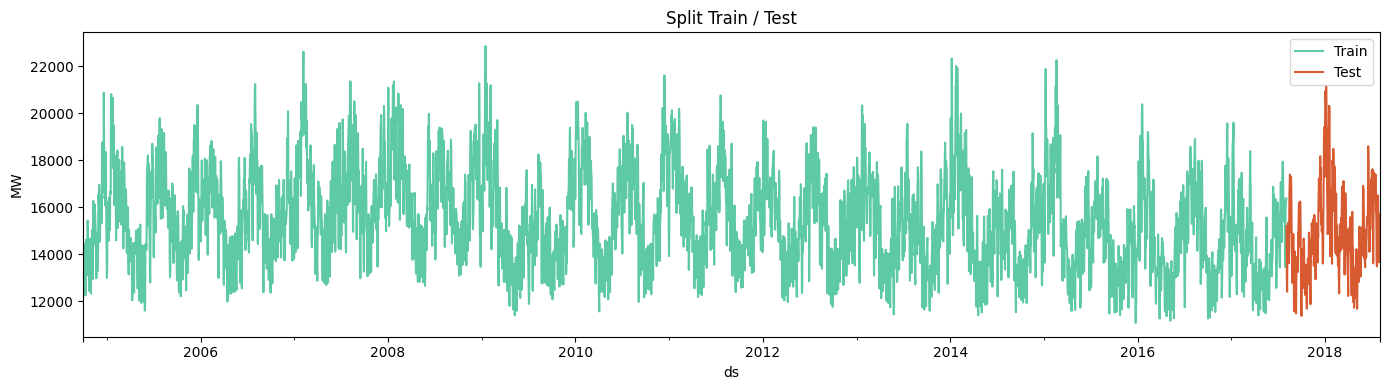

In [3]:
# On garde les 365 derniers jours pour le test
split_date = '2017-08-03'

train = df_daily[df_daily['ds'] <= split_date]
test  = df_daily[df_daily['ds'] >  split_date]

print(f"Train : {len(train)} jours ({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"Test  : {len(test)} jours ({test['ds'].min().date()} → {test['ds'].max().date()})")

# Visualisation du split
fig, ax = plt.subplots(figsize=(14, 4))
train.set_index('ds')['y'].plot(ax=ax, color='#5DCAA5', label='Train')
test.set_index('ds')['y'].plot(ax=ax, color='#D85A30', label='Test')
ax.set_title("Split Train / Test")
ax.set_ylabel("MW")
ax.legend()
plt.tight_layout()
plt.show()

# Entraînement Prophet

In [4]:
# Prophet détecte automatiquement tendance + saisonnalité
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

model_prophet.fit(train)
print("Prophet entraîné !")

Prophet entraîné !


# Prédictions et évaluation

In [5]:
# Prédiction sur la période de test
future = model_prophet.make_future_dataframe(periods=len(test), freq='D')
forecast = model_prophet.predict(future)

# On extrait les prédictions sur le test set uniquement
forecast_test = forecast[forecast['ds'] > split_date][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_test = forecast_test.reset_index(drop=True)
test = test.reset_index(drop=True)

# Métriques
mae  = mean_absolute_error(test['y'], forecast_test['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))
mape = (abs(test['y'] - forecast_test['yhat']) / test['y']).mean() * 100

print("=== Résultats Prophet ===")
print(f"MAE  : {mae:.0f} MW")
print(f"RMSE : {rmse:.0f} MW")
print(f"MAPE : {mape:.2f}%")

=== Résultats Prophet ===
MAE  : 1247 MW
RMSE : 1641 MW
MAPE : 7.98%


# Visualisation des prédictions

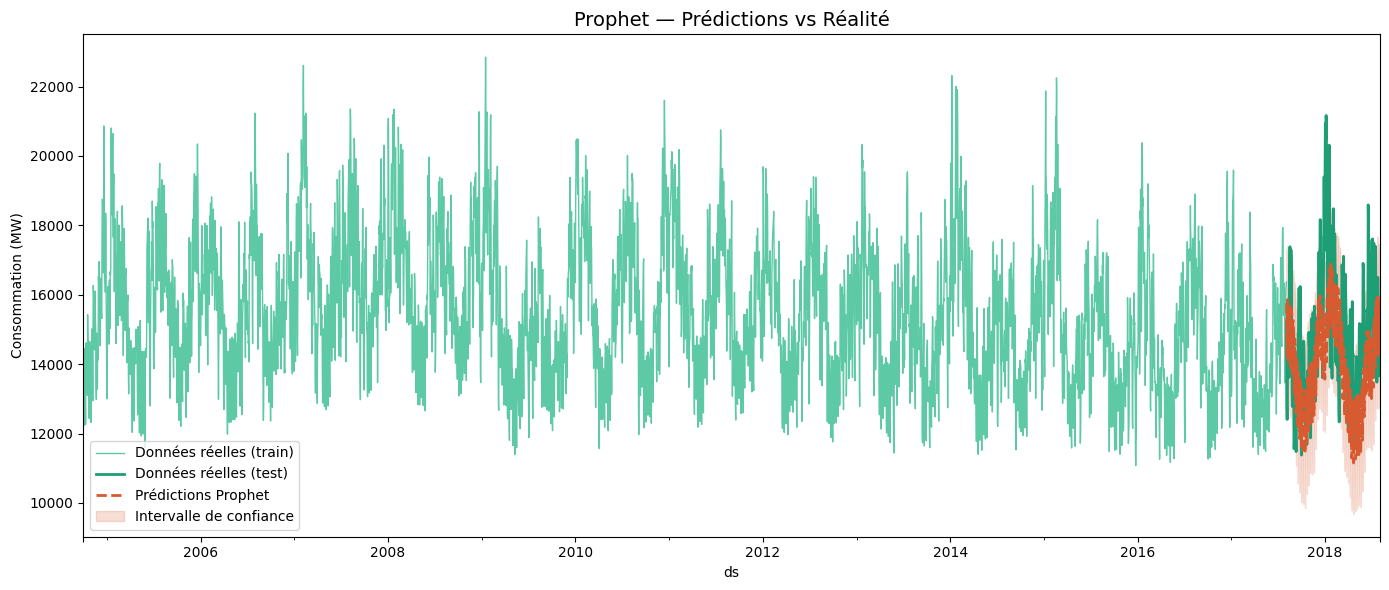

In [7]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

# Train
train.set_index('ds')['y'].plot(ax=ax, color='#5DCAA5',
                                 linewidth=1, label='Données réelles (train)')
# Test réel
test.set_index('ds')['y'].plot(ax=ax, color='#1D9E75',
                                linewidth=2, label='Données réelles (test)')
# Prédictions
forecast_test.set_index('ds')['yhat'].plot(ax=ax, color='#D85A30',
                                            linewidth=2, linestyle='--',
                                            label='Prédictions Prophet')
# Intervalle de confiance
ax.fill_between(mdates.date2num(forecast_test['ds']),
                forecast_test['yhat_lower'],
                forecast_test['yhat_upper'],
                alpha=0.2, color='#D85A30', label='Intervalle de confiance')

ax.set_title("Prophet — Prédictions vs Réalité", fontsize=14)
ax.set_ylabel("Consommation (MW)")
ax.legend()
plt.tight_layout()
plt.show()

# Composantes du modèle

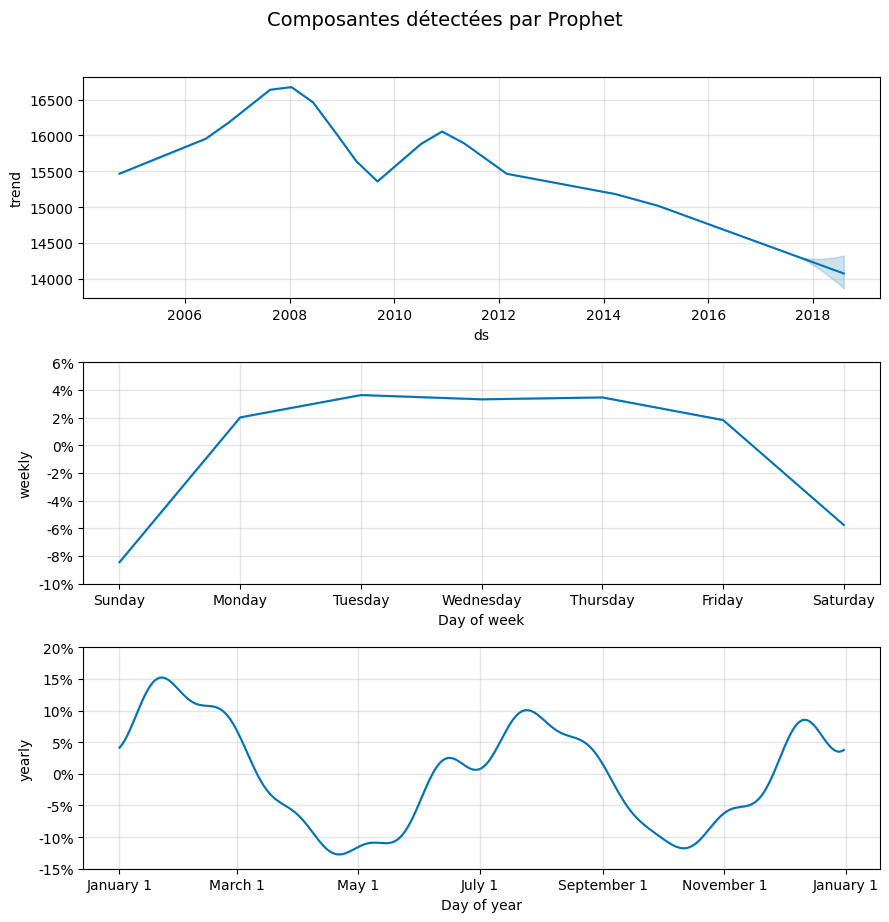

In [8]:
# Prophet décompose automatiquement la série
fig = model_prophet.plot_components(forecast)
plt.suptitle("Composantes détectées par Prophet", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Préparation des données pour LSTM

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# Rechargement propre
df = pd.read_csv('AEP_hourly.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime').sort_index()
df_daily = df['AEP_MW'].resample('D').mean().dropna()

# Normalisation entre 0 et 1 — indispensable pour les réseaux de neurones
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_daily.values.reshape(-1, 1))

# Fonction pour créer les séquences
# LSTM apprend : "étant donné les 60 derniers jours, prédit le suivant"
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 60  # on utilise 60 jours pour prédire le suivant
X, y = create_sequences(data_scaled, SEQ_LENGTH)

# Split train/test (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Conversion en tenseurs PyTorch
X_train = torch.FloatTensor(X_train)
X_test  = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test  = torch.FloatTensor(y_test)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print("Données prêtes pour LSTM !")

X_train shape : torch.Size([3996, 60, 1])
X_test shape  : torch.Size([999, 60, 1])
Données prêtes pour LSTM !


# Architecture LSTM

In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = 0.2
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # On prend seulement la dernière sortie
        out = self.fc(lstm_out[:, -1, :])
        return out

# Initialisation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_lstm = LSTMModel().to(device)

print(f"Modèle LSTM créé — utilise : {device}")
print(f"\nArchitecture :")
print(model_lstm)

Modèle LSTM créé — utilise : cuda

Architecture :
LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


# Entraînement LSTM

Epoch 10/50 — Loss: 0.006906
Epoch 20/50 — Loss: 0.004577
Epoch 30/50 — Loss: 0.004154
Epoch 40/50 — Loss: 0.004013
Epoch 50/50 — Loss: 0.004013

Entraînement terminé !


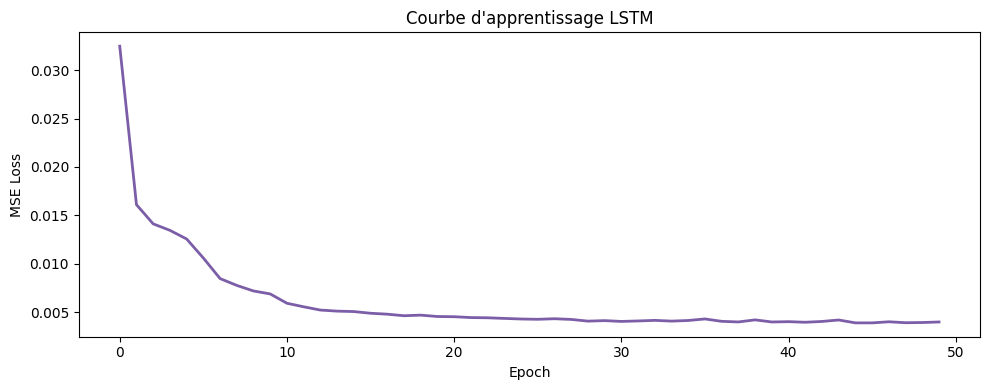

In [11]:
# Hyperparamètres
EPOCHS     = 50
BATCH_SIZE = 32
LR         = 0.001

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=LR)

# DataLoader
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Entraînement
train_losses = []

model_lstm.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        output = model_lstm(X_batch)
        loss   = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {avg_loss:.6f}")

print("\nEntraînement terminé !")

# Courbe de loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, color='#7B5EA7', linewidth=2)
ax.set_title("Courbe d'apprentissage LSTM")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
plt.tight_layout()
plt.show()

# Évaluation et comparaison finale

In [12]:
# Prédictions LSTM
model_lstm.eval()
with torch.no_grad():
    y_pred_lstm = model_lstm(X_test.to(device)).cpu().numpy()

# Dénormalisation
y_pred_lstm_real = scaler.inverse_transform(y_pred_lstm)
y_test_real      = scaler.inverse_transform(y_test.numpy())

# Métriques LSTM
mae_lstm  = mean_absolute_error(y_test_real, y_pred_lstm_real)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, y_pred_lstm_real))
mape_lstm = (abs(y_test_real - y_pred_lstm_real) / y_test_real).mean() * 100

print("=== Comparaison Prophet vs LSTM ===")
print(f"{'Modèle':<20} {'MAE':>10} {'RMSE':>10} {'MAPE':>10}")
print("-" * 52)
print(f"{'Prophet':<20} {mae:>10.0f} {rmse:>10.0f} {mape:>9.2f}%")
print(f"{'LSTM':<20} {mae_lstm:>10.0f} {rmse_lstm:>10.0f} {mape_lstm:>9.2f}%")

=== Comparaison Prophet vs LSTM ===
Modèle                      MAE       RMSE       MAPE
----------------------------------------------------
Prophet                    1247       1641      7.98%
LSTM                        537        720      3.61%


# Visualisation finale

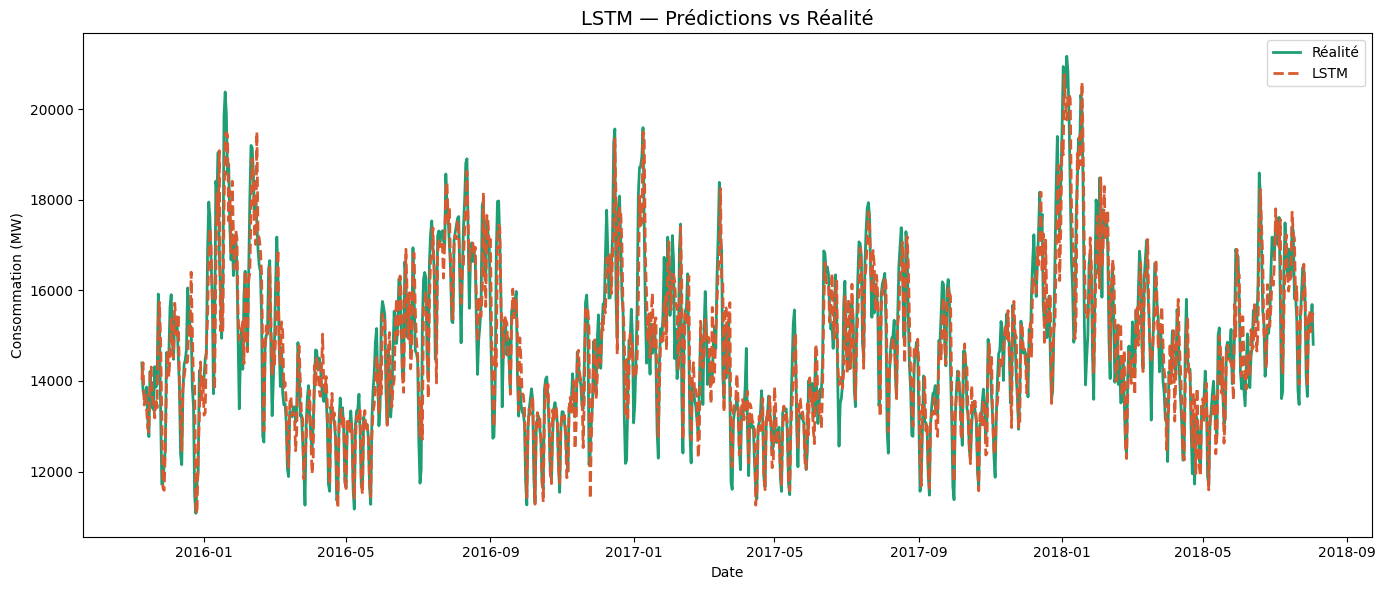

In [13]:
# Index temporel pour le test
dates_test = df_daily.index[SEQ_LENGTH + split:]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates_test, y_test_real,
        color='#1D9E75', linewidth=2, label='Réalité')
ax.plot(dates_test, y_pred_lstm_real,
        color='#D85A30', linewidth=2, linestyle='--', label='LSTM')

ax.set_title("LSTM — Prédictions vs Réalité", fontsize=14)
ax.set_ylabel("Consommation (MW)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

# Sauvegarde

In [14]:
import joblib

# Sauvegarde LSTM
torch.save(model_lstm.state_dict(), 'lstm_model.pth')
joblib.dump(scaler, 'scaler.pkl')

# Sauvegarde des métriques pour l'app
metrics = {
    'prophet': {'mae': mae, 'rmse': rmse, 'mape': mape},
    'lstm':    {'mae': mae_lstm, 'rmse': rmse_lstm, 'mape': mape_lstm}
}
joblib.dump(metrics, 'metrics.pkl')

print("Modèles et métriques sauvegardés !")

Modèles et métriques sauvegardés !
